# **Task 1**

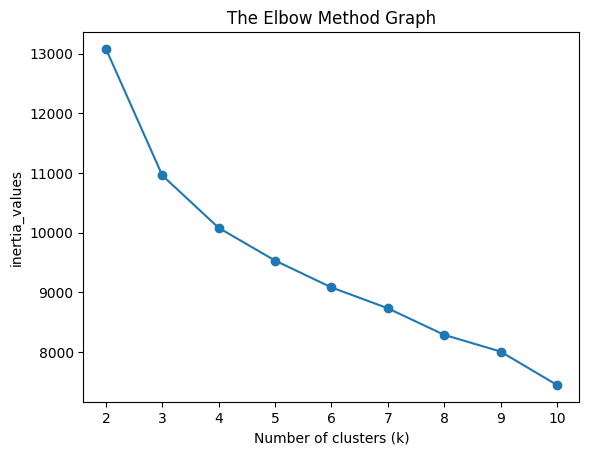

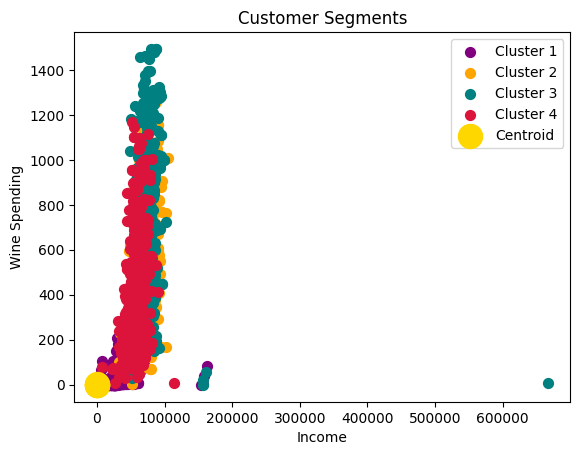

         ID   Income  MntWines  MntMeatProducts  Cluster
0      5524  58138.0       635              546        1
1      2174  46344.0        11                6        0
2      4141  71613.0       426              127        3
3      6182  26646.0        11               20        0
4      5324  58293.0       173              118        3
...     ...      ...       ...              ...      ...
2235  10870  61223.0       709              182        1
2236   4001  64014.0       406               30        3
2237   7270  56981.0       908              217        2
2238   8235  69245.0       428              214        2
2239   9405  52869.0        84               61        0

[2240 rows x 5 columns]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('marketing_campaign.csv', sep=',')

selected_columns = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

customer_data = data[selected_columns].copy()
customer_data = customer_data.fillna(customer_data.median())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)

inertia_values = []
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, init='k-means++', random_state=42)
    model.fit(scaled_data)
    inertia_values.append(model.inertia_)

plt.plot(range(2, 11), inertia_values, marker='o')
plt.title('The Elbow Method Graph')
plt.xlabel('Number of clusters (k)')
plt.ylabel('inertia_values')
plt.show()

kmeans_model = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_result = kmeans_model.fit_predict(scaled_data)
data['Cluster'] = cluster_result

cluster_colors = ['purple', 'orange', 'teal', 'crimson']
cluster_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for index in range(4):
    plt.scatter(customer_data['Income'][cluster_result == index], customer_data['MntWines'][cluster_result == index], s=50, c=cluster_colors[index], label=cluster_labels[index])

plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], s=300, c='gold', label='Centroid')

plt.title('Customer Segments')
plt.xlabel('Income')
plt.ylabel('Wine Spending')
plt.legend()
plt.show()

print(data[['ID', 'Income', 'MntWines', 'MntMeatProducts', 'Cluster']])